In [1]:
import os
import sys
import pandas as pd
import umap
import cv2
import seaborn as sns
import scipy
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from MulticoreTSNE import MulticoreTSNE as TSNE
import matplotlib.pyplot as plt
from collections import defaultdict
from cv_tools.utils import COCOEvalPlus
import os
from cv_tools import utils
import config as C
import plot_utils as pu

%load_ext autoreload
%autoreload 1
%aimport config
%aimport cv_tools.utils
%aimport plot_utils

data_dir = C.DATA_DIR
results_dir = C.RESULTS_DIR
_ = C.setup_plotting(rc=C.RC_PAPER)

/Users/s2785075/miniconda3/envs/cv_tools/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DeepFish NONE 0.5664568811868474 0.5802602964460901 0.7211538195724904 0.7660260630538676
DeepFish resized_MSRCR_15_80_250_new 0.09109499972710702 0.1889840642510527 0.3152238478777577 0.46887676484788515
GLOW_low_visibility_estuaries NONE 0.7149841032341326 0.6765866883492315 0.7131660732460195 0.7157260388851756
GLOW_low_visibility_estuaries resized_MSRCR_15_80_250_new -0.14866056849318854 -0.08929018975623403 0.04075018491272839 0.13191409605049004
Jellytoring NONE -0.3137845407909724 -0.14099595675257276 0.0047995712267666045 0.07903582938438333
Jellytoring resized_MSRCR_15_80_250_new -0.45550318450610733 -0.3516827478163893 -0.25496921774678066 -0.20055234204850755
S-UODAC NONE 0.9241455080542322 0.6487912962092404 0.6210738414667497 0.48810465880649134
S-UODAC resized_MSRCR_15_80_250_new 0.02958387501312648 0.036342240076140286 0.03488746277412437 0.03176913311319812


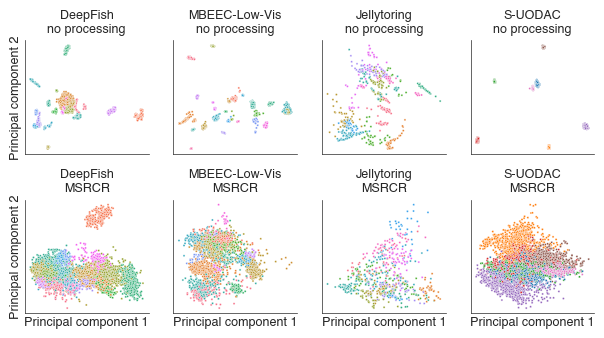

In [2]:
reducer_name = 'PCA'
resize = 256
datasets = C.MAIN_DATASETS + ['S-UODAC']
fig, axs = plt.subplots(2, len(datasets), figsize=((14 * (len(datasets) / 3)) * C.CM, 9 * C.CM))
plt.subplots_adjust(hspace=0.4)
PC1_outliers = {}
for col, d in enumerate(datasets):
    PC1_outliers[d] = {}
    for row, pp in enumerate(['NONE', 'resized_MSRCR_15_80_250_new']):
        annot_fn, img_dir = C.DATASETS[d]
        dataset = utils.read_json(annot_fn.replace('resources', 'resources_jsons'), verbose=False)
        fn = os.path.join(results_dir, 'silhouette', f'{d}.{reducer_name}.{pp}.{resize}px.npz')
        data = np.load(fn)
        metadata = data['metadata']
        img_arr = data['img_arr']
        assert len(dataset['images']) == len(metadata)
        PC1_outliers[d][pp] = metadata[np.argmax(img_arr[:, 1])]
        print(d, pp, data['S2'], data['S3'], data['S5'], data['S10'])
        
        if d == 'Jellytoring':
            df = pd.read_csv(os.path.join(data_dir, 'resources_jsons', d, f'{d}.csv'), index_col='img_id')
            df = df.loc[~df.index.duplicated(), ['filename', 'width', 'height', 'group']]
            counts_per_groups = df.groupby('group')['filename'].count()
            jelly_groups = counts_per_groups.loc[counts_per_groups >= 40].sort_values().index.values
            mask = np.asarray([g in jelly_groups for g in metadata[:, -1]])
            metadata = metadata[mask]
            img_arr = img_arr[mask]
            
        idx = np.arange(len(metadata))
        np.random.shuffle(idx)
        
        ax = sns.scatterplot(x=img_arr[idx, 0], y=img_arr[idx, 1], hue=metadata[idx, -1], marker='.', ax=axs[row, col], rasterized=True)
        title = f"{'no processing' if pp == 'NONE' else C.RENAME_PPS.get(pp, pp)}"
        title = f"{d.replace('GLOW_low_visibility_estuaries', 'MBEEC-Low-Vis')}\n{title}"
        ax.set_title(title)
        ax.legend(bbox_to_anchor=(1, 1)).set_visible(False)
        ax.tick_params(
            axis='both',
            which='both',
            bottom=False,
            left=False,
            labelbottom=False,
            labelleft=False)
        if row == 1:
            ax.set_xlabel('Principal component 1')
        if col == 0:
            ax.set_ylabel('Principal component 2')
        sns.despine()
utils.savefig(os.path.join(C.RESULTS_DIR, 'figures', f'NEW.{reducer_name}{".with_S-UODAC" if "S-UODAC" in datasets else ""}'), dpi=1200)
plt.show()

dt2
dt2 DeepFish resized_MSRCR_15_80_250_new has the best NMSS
dt2 GLOW_low_visibility_estuaries resized_MSRCR_15_80_250_new has the best NMSS
dt2 Jellytoring resized_MSRCR_15_80_250_new has the best NMSS


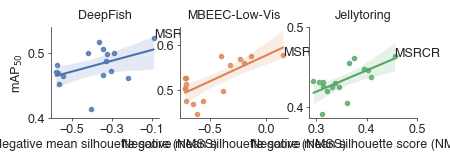

DeepFish PearsonRResult(statistic=0.4335286340230881, pvalue=0.09342863088771101) N = 16
GLOW_low_visibility_estuaries PearsonRResult(statistic=0.7219760449151694, pvalue=0.001588566792486474) N = 16
Jellytoring PearsonRResult(statistic=0.6251690118499029, pvalue=0.009607462435463347) N = 16


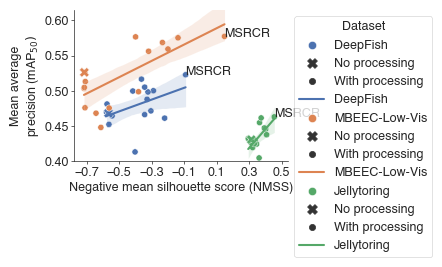

yolo8
yolo8 DeepFish resized_MSRCR_15_80_250_new has the best NMSS
yolo8 GLOW_low_visibility_estuaries resized_MSRCR_15_80_250_new has the best NMSS
yolo8 Jellytoring resized_MSRCR_15_80_250_new has the best NMSS


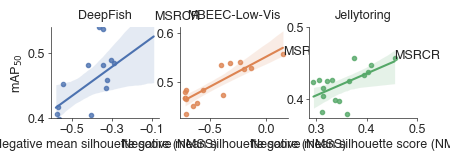

DeepFish PearsonRResult(statistic=0.589646109445123, pvalue=0.016218503069818316) N = 16
GLOW_low_visibility_estuaries PearsonRResult(statistic=0.8611508663932149, pvalue=1.833476359891158e-05) N = 16
Jellytoring PearsonRResult(statistic=0.5768873284115856, pvalue=0.01930709661421743) N = 16


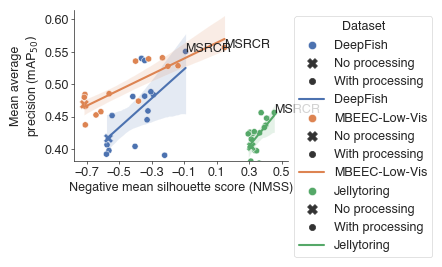

In [5]:
NMSS_COL = 'S2' # 'S5' 'S10'
ANNOT_LABEL = 'resized_MSRCR_15_80_250_new'

reducer_name = 'PCA'
resize = 256
eval_type = 'Groups'
for model in ['dt2', 'yolo8']:
    print(model)
    store = defaultdict(lambda: defaultdict(list))
    for dataset in C.MAIN_DATASETS:
        for pp in [None] + C.ALL_PPS:
            r = pu.get_results(model=model, dataset=dataset, eval_type=eval_type, augm=pp, model_select='best',
                               split='test', pickle_prefix=os.path.join(results_dir, 'pickles', 'FINAL_GROUPS'))
            # mAP = np.mean([r[s].stats['mAP50'] for s in r])
            mAP = np.mean([r[s].precision.mean(axis=0).mean() for s in r])
            # del r
            data = np.load(os.path.join(
                results_dir, 'silhouette', f'{dataset}.{reducer_name}.{pp}.{resize}px.npz'
            ))

            store[dataset]['pp'].append(pp)
            store[dataset]['mAP'].append(mAP)
            for s in ['S2', 'S3', 'S5', 'S10']:
                store[dataset][s].append(float(data[s]))

    fig, axs = plt.subplots(1, 3, figsize=(12 * C.CM, 3 * C.CM))
    for color, (ax, dataset) in enumerate(zip(axs, C.MAIN_DATASETS)):
        x = -1 * np.asarray(store[dataset][NMSS_COL])
        y = np.asarray(store[dataset]['mAP'])
        mask = np.asarray(store[dataset]['pp'])
        ax = sns.regplot(x=x[::-1], y=y[::-1], label=dataset, ci=95, color=sns.color_palette('deep')[color], ax=ax)
        if x[mask == ANNOT_LABEL].squeeze() == np.max(x):
            print(model, dataset, ANNOT_LABEL, 'has the best NMSS')
        ax.text(x[mask == ANNOT_LABEL].squeeze(), y[mask == ANNOT_LABEL].squeeze(), C.RENAME_PPS.get(ANNOT_LABEL, ANNOT_LABEL))
        ax.set_xlabel('Negative mean silhouette score (NMSS)')
        if color == 0:
            ax.set_ylabel('mAP$_{50}$')
        if dataset == 'DeepFish':
            ax.set_xticks(-1 * np.arange(0.1, 0.7, 0.2))
            ax.set_ylim((0.4, 0.54))
            ax.set_yticks(np.arange(0.4, 0.6, 0.1))
        elif dataset == 'GLOW_low_visibility_estuaries':
            ax.set_yticks(np.arange(0.5, 0.7, 0.1))
        elif dataset == 'Jellytoring':
            ax.set_xticks(-1 * np.arange(-0.5, -0.2, 0.1))
            ax.set_yticks(np.arange(0.4, 0.6, 0.1))
        ax.set_title(C.RENAME_DATASETS.get(dataset, dataset))
        sns.despine()
    utils.savefig(os.path.join(C.RESULTS_DIR, 'figures', f'silhouette.{model}'))
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(7 * C.CM, 5 * C.CM))
    for color, dataset in enumerate(C.MAIN_DATASETS):
        no_processing = ['No processing' if pp is None else 'With processing' for pp in store[dataset]['pp']]
        x = -1 * np.asarray(store[dataset][NMSS_COL])
        y = np.asarray(store[dataset]['mAP'])
        mask = np.asarray(store[dataset]['pp'])
        ax = sns.scatterplot(
            x=x[::-1],
            y=y[::-1],
            style=no_processing[::-1],
            size=no_processing[::-1],
            sizes=[50, 20],
            size_order=['No processing', 'With processing'],
            style_order=['No processing', 'With processing'],
            markers=['X', 'o'],
            color=sns.color_palette('deep')[color],
            label=C.RENAME_DATASETS.get(dataset, dataset),
            alpha=1,
            # s=20,
            ax=ax
        )

        ax = sns.regplot(
            x=x[::-1],
            y=y[::-1],
            ci=95,
            color=sns.color_palette('deep')[color],
            label=C.RENAME_DATASETS.get(dataset, dataset),
            scatter=False,
            ax=ax
        )

        ax.text(x[mask == ANNOT_LABEL].squeeze(), y[mask == ANNOT_LABEL].squeeze(), C.RENAME_PPS.get(ANNOT_LABEL, ANNOT_LABEL))
        ax.set_xlabel('Negative mean silhouette score (NMSS)')
        ax.set_ylabel('Mean average\nprecision (mAP$_{50})$')
        ax.legend(bbox_to_anchor=(1, 1), title='Dataset')
        ax.set_xticks(np.arange(-0.7, 0.51, 0.2))
        ax.set_yticks(np.arange(0.4, 0.66, 0.05))
        ax.set_xlim((-0.7772696969025386, 0.5386456828095971))
        ax.set_ylim((ax.get_ylim()[0], 0.615))
        sns.despine()

        print(dataset, scipy.stats.pearsonr(x, y), 'N =', len(x))

    utils.savefig(os.path.join(C.RESULTS_DIR, 'figures', f'silhouette_in_one.{model}'))
    plt.show()

In [6]:
for dataset in store:
    print(dataset)
    df = pd.DataFrame.from_dict(store[dataset]).drop('mAP', axis=1).set_index('pp').rename({None: 'NONE'}).sort_values('S2')
    df.index.name = None
    df.to_csv(f'../results/silhouettes.{dataset}.csv')
    display(df)

DeepFish


,S2,S3,S5,S10
resized_MSRCR_15_80_250_new,0.091095,0.188984,0.315224,0.468877
FUnIE-GAN,0.220319,0.417006,0.674453,0.760888
ARCR,0.289565,0.485354,0.618570,0.710745
CAP,0.304922,0.489686,0.630438,0.709892
ace,0.322997,0.546363,0.665735,0.763156
autocontrast,0.328440,0.508937,0.622784,0.721603
grey_world,0.343254,0.531276,0.661700,0.723458
DCP,0.343397,0.487290,0.623397,0.755369
MLLE,0.363216,0.592573,0.667693,0.787212
adjust_sigmoid,0.402626,0.541333,0.720210,0.778839


GLOW_low_visibility_estuaries


,S2,S3,S5,S10
resized_MSRCR_15_80_250_new,-0.148661,-0.089290,0.040750,0.131914
ace,0.137823,0.397340,0.451206,0.479133
grey_world,0.199798,0.483623,0.610275,0.616133
autocontrast,0.233970,0.410135,0.451610,0.505109
ARCR,0.319193,0.459236,0.528406,0.544398
DCP,0.381375,0.510908,0.646302,0.671064
MLLE,0.399321,0.556107,0.604876,0.654149
CAP,0.562205,0.617849,0.682872,0.697881
FUnIE-GAN,0.613121,0.598891,0.668797,0.672919
adjust_sigmoid,0.643141,0.635889,0.700089,0.705779


Jellytoring


,S2,S3,S5,S10
resized_MSRCR_15_80_250_new,-0.455503,-0.351683,-0.254969,-0.200552
ARCR,-0.407982,-0.251903,-0.116992,-0.012849
MLLE,-0.401848,-0.275086,-0.129523,-0.063085
ace,-0.393991,-0.222057,-0.091220,0.010672
autocontrast,-0.374251,-0.210791,-0.067972,0.024430
grey_world,-0.364471,-0.251487,-0.078615,-0.031863
adjust_sigmoid,-0.361646,-0.192718,-0.039593,0.035008
DCP,-0.346094,-0.179161,-0.032655,0.041491
FUnIE-GAN,-0.336410,-0.164761,-0.013167,0.063839
adjust_gamma_up,-0.332107,-0.151132,-0.004188,0.066759
